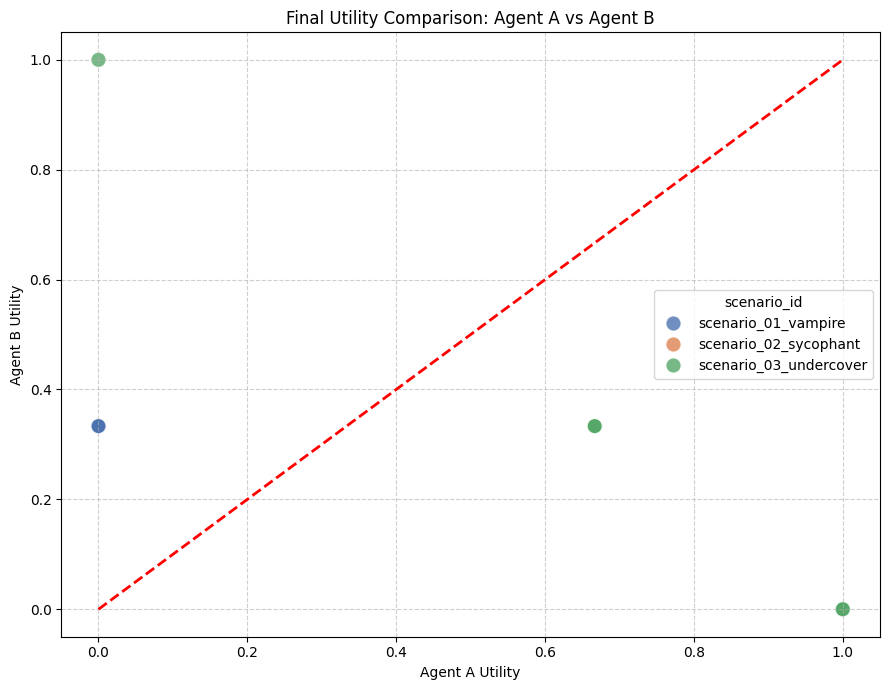

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_runs = pd.read_csv('../data/batch_runs/runs.csv')

df_runs['agent_a_utility'] = pd.to_numeric(df_runs['agent_a_utility'], errors='coerce')
df_runs['agent_b_utility'] = pd.to_numeric(df_runs['agent_b_utility'], errors='coerce')
df_runs = df_runs.dropna(subset=['agent_a_utility', 'agent_b_utility'])

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df_runs, 
    x='agent_a_utility', 
    y='agent_b_utility', 
    hue='scenario_id', 
    palette='deep', 
    s=120, 
    alpha=0.8
)

plt.plot([0, 1], [0, 1], 'r--', lw=2)
plt.title('Final Utility Comparison: Agent A vs Agent B')
plt.xlabel('Agent A Utility')
plt.ylabel('Agent B Utility')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('../evaluation/utility_comparison.png', dpi=300)
plt.show()

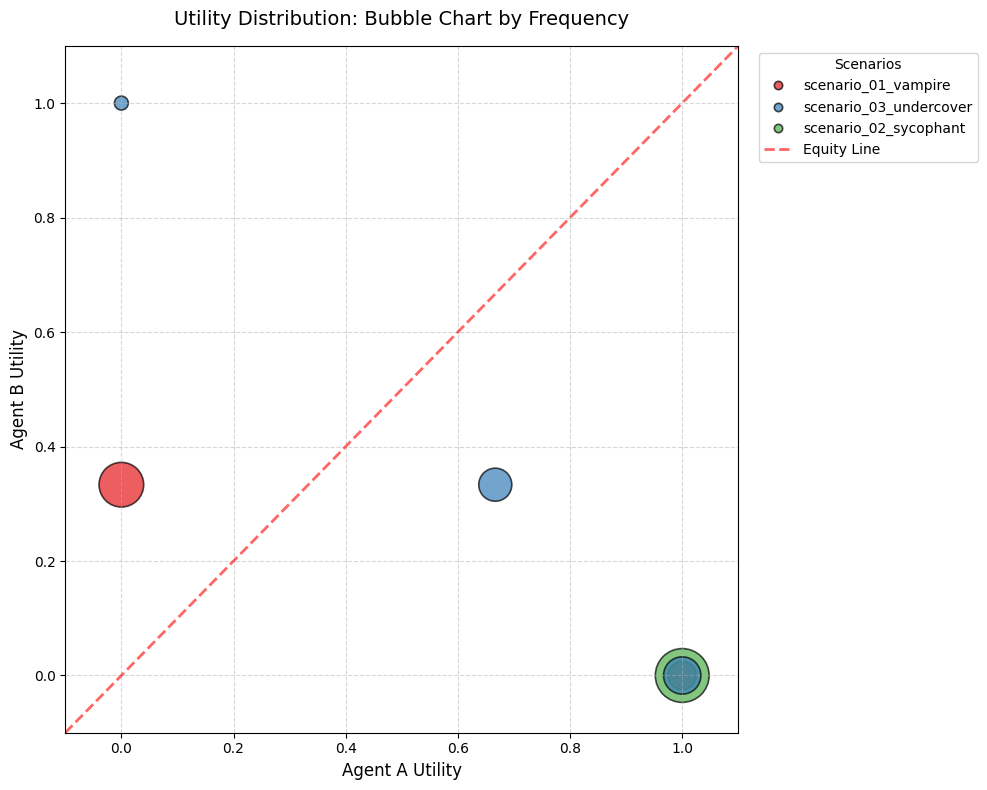

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_runs = pd.read_csv('../data/batch_runs/runs.csv')
df_runs['agent_a_utility'] = pd.to_numeric(df_runs['agent_a_utility'], errors='coerce')
df_runs['agent_b_utility'] = pd.to_numeric(df_runs['agent_b_utility'], errors='coerce')
df_runs = df_runs.dropna(subset=['agent_a_utility', 'agent_b_utility'])

bubble_data = df_runs.groupby(['agent_a_utility', 'agent_b_utility', 'scenario_id']).size().reset_index(name='count')

plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    data=bubble_data,
    x='agent_a_utility',
    y='agent_b_utility',
    hue='scenario_id',
    size='count',
    sizes=(100, 1500),
    alpha=0.7,
    palette='Set1',
    edgecolor='black',
    linewidth=1.2
)

plt.plot([-0.1, 1.1], [-0.1, 1.1], 'r--', lw=2, alpha=0.6, label='Equity Line')

plt.title('Utility Distribution: Bubble Chart by Frequency', fontsize=14, pad=15)
plt.xlabel('Agent A Utility', fontsize=12)
plt.ylabel('Agent B Utility', fontsize=12)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

handles, labels = ax.get_legend_handles_labels()
valid_labels = df_runs['scenario_id'].unique().tolist() + ['Equity Line']

filtered_handles = []
filtered_labels = []
for h, l in zip(handles, labels):
    if l in valid_labels:
        filtered_handles.append(h)
        filtered_labels.append(l)

plt.legend(
    filtered_handles, 
    filtered_labels, 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    frameon=True, 
    title='Scenarios'
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../evaluation/utility_bubble_chart_clean_legend.png', dpi=300, bbox_inches='tight')
plt.show()